In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df
#Benign tumor - not serious /non cancerous,grows slowly,does not spread /easy to remove
# it takes place in lipoma(under skin),Fibroid(uterus),Adenoma(in glands)
#Malignant Tumor- Cancerous growth of cells/spreads to other organs/grow fast
# occurs in lung,breast..


,id,diagnosis,Radius_mean,Texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,21.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   Radius_mean              569 non-null    float64
 3   Texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isnull().sum()

id                         0
diagnosis                  0
Radius_mean                0
Texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [6]:
df.describe()  # Statistical Measure

,id,Radius_mean,Texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.296678,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301816,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.870000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
print('Dataset shape',df.shape)

print('\nColumns:\n',df.columns)

Dataset shape (569, 32)

Columns:
 Index(['id', 'diagnosis', 'Radius_mean', 'Texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [8]:
# checking the distribution of target variable

In [9]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

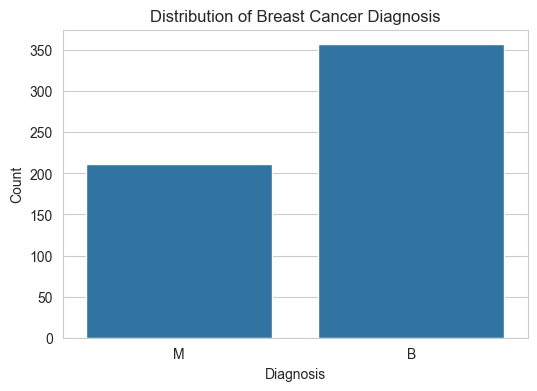

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution of Breast Cancer Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [11]:
# For particular category wise want to see the mean,var,...
# groupby me based on diagnosis value it will calculate mean for all the cols associated with it in numeric form
df.groupby('diagnosis').mean()

,id,Radius_mean,Texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,2.654382e+07,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,3.681805e+07,17.462830,21.623774,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


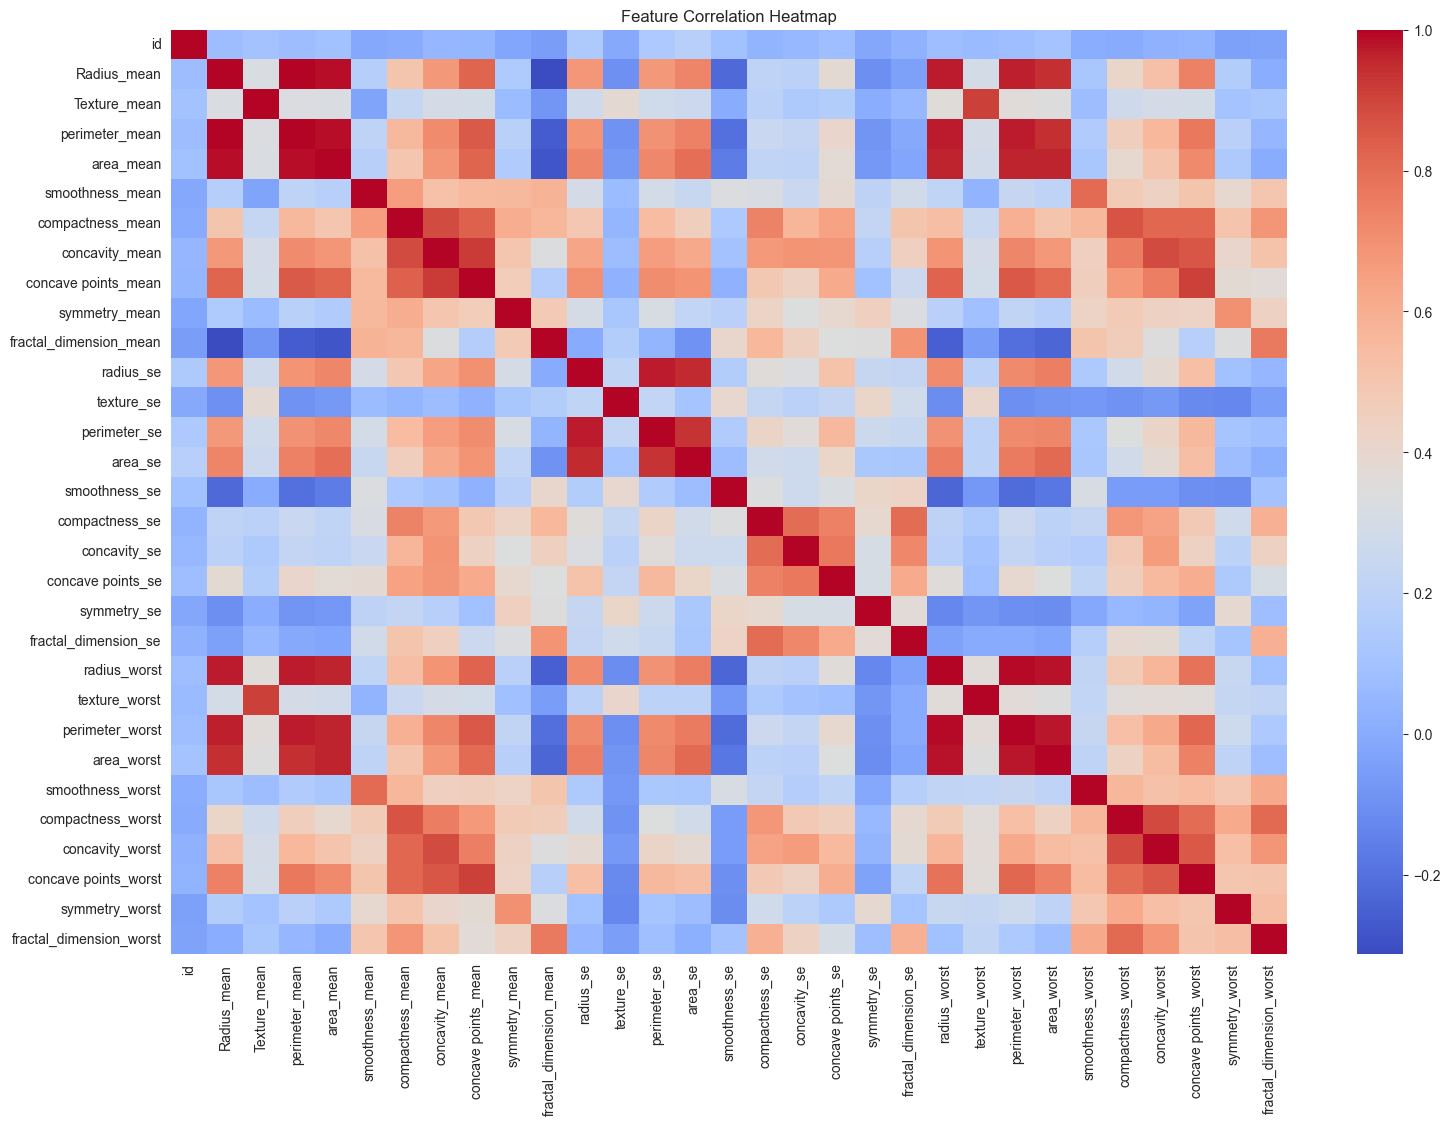

In [12]:
plt.figure(figsize=(18,12))
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Boxplot for outlier Detection

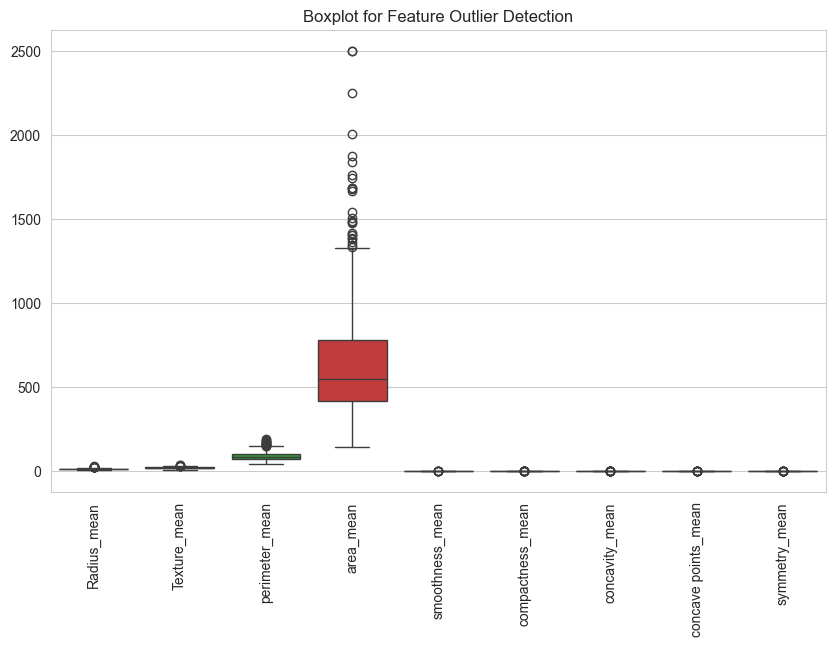

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:,1:11])
plt.xticks(rotation=90)
plt.title('Boxplot for Feature Outlier Detection')
plt.show()

# Separating the feature and target

In [14]:
x = df.drop(columns = 'diagnosis')

In [15]:
y = df['diagnosis']

In [16]:
x.head()

,id,Radius_mean,Texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,20.57,21.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=2)
print('x.shape,x_train.shape',x.shape,x_train.shape) # 80 % of the data in t

x.shape,x_train.shape (569, 31) (455, 31)


# Model Training

# Standard Scaler

In [32]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling, so that LR will be performed better with scaled data
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape
print(scaler.n_features_in_)

31


random_state = 2 → same result every run 🔁
random_state = 42 → same result (but different from 2)
No random_state → different every time 🎲

# logistic Regression

In [19]:
clf = LogisticRegression()
clf.fit(x_train,y_train)
x_train


array([[-0.2394432 , -0.01330339,  1.7757658 , ..., -0.13236958,
        -1.08014517, -0.03527943],
       [ 0.47435907, -0.8448276 , -0.6284278 , ..., -1.11552632,
        -0.85773964, -0.72098905],
       [-0.23982301,  1.44755936,  0.71180168, ...,  0.87583964,
         0.4967602 ,  0.46321706],
       ...,
       [-0.23953211, -0.46608541, -1.49375484, ..., -1.32388956,
        -1.02997851, -0.75145272],
       [ 0.48265433, -0.50025764, -1.62161319, ..., -0.0987626 ,
         0.35796577, -0.43906159],
       [-0.17757265,  0.96060511,  1.21181916, ...,  0.8956983 ,
        -1.23064515,  0.50697397]], shape=(455, 31))

In [20]:
y_test_predict = clf.predict(x_test)
lr_acc = accuracy_score(y_test_predict,y_test)
lr_acc

0.9649122807017544

# Model Accuracy Visualization

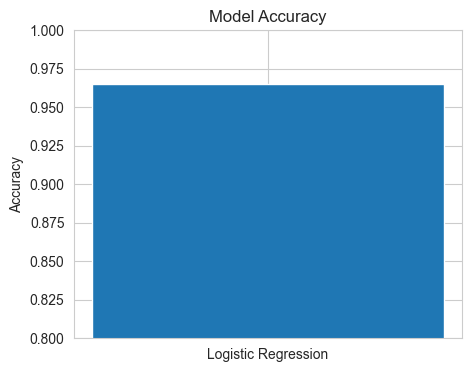

Accuracy Score: 0.9649122807017544


In [21]:
lr_acc = accuracy_score(y_test_predict,y_test)
plt.figure(figsize=(5,4))
plt.bar(['Logistic Regression'], [lr_acc])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

print('Accuracy Score:', lr_acc)

# Confusion Matrix

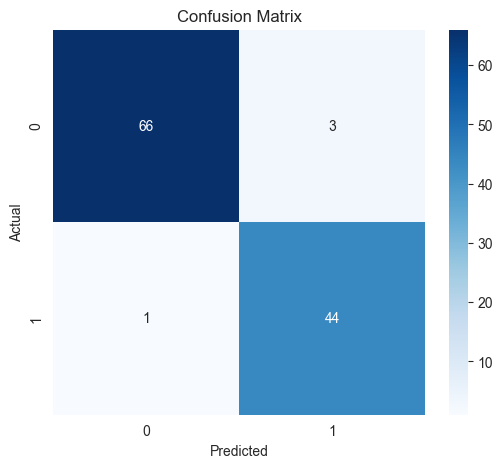

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_predict)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report

In [23]:
# adds precision ,f1-score,recall
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           B       0.99      0.96      0.97        69
           M       0.94      0.98      0.96        45

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



# ROC Curve

Text(0.5, 1.0, 'ROC Curve')

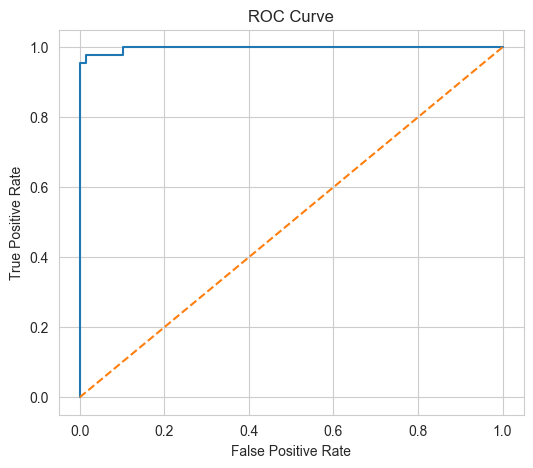

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

# Convert target labels into binary
# M = 1, B = 0

y_test_binary = y_test.map({'M':1, 'B':0})

# Probability prediction
probabilities = clf.predict_proba(x_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test_binary, probabilities)
auc_score = roc_auc_score(y_test_binary, probabilities)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

# Comparision of Multiple Models

In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(x_train, y_train)

rf_predict = rf.predict(x_test)

rf_accuracy = accuracy_score(y_test, rf_predict)

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.9649122807017544
Random Forest Accuracy: 0.9385964912280702


# Visualization for Model Comparision

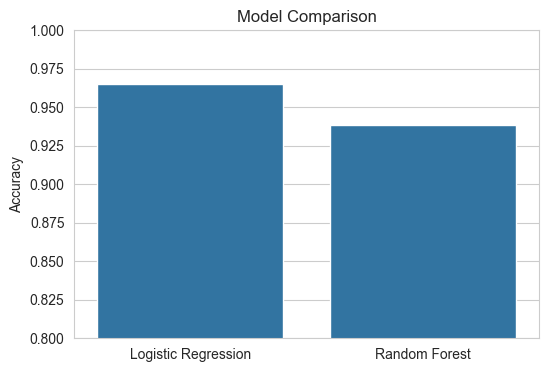

In [26]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_acc, rf_accuracy]

plt.figure(figsize=(6,4))

sns.barplot(x=models, y=accuracies)

plt.ylim(0.8,1.0)

plt.title('Model Comparison')

plt.ylabel('Accuracy')

plt.show()

# Building Predictive System

In [27]:
input_data = (843786,12.45,15.7,82.57,477.1,0.1278,0.17,0.1578,0.08089,0.2087,0.07613,0.3345,0.8902,2.217,27.19,0.00751,0.03345,0.03672,0.01137,0.02165,0.005082,15.47,23.75,103.4,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.1244)
# change the input data (tuple form) to a numpy array
#input_data_as_numpy_array = np.asarray(input_data)
# reshape the numpy array as we are predicting for one datapoint(model should come to know that we have to predict only one col)
#input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# convert to dataframe 
input_data_as_pd = pd.DataFrame([input_data])

# Option 2: Use numpy array directly (commented out the original approach)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = clf.predict(input_data_as_pd)
print(prediction)


['M']


In [28]:
if(prediction =='M'):
     print('The Breast cancer is Malignant')
else:
    print('The Breast cancer is Benign')

The Breast cancer is Malignant


# Save Model
In this ,notebook converts into actual predictive system


In [29]:
import pickle

# Save model
pickle.dump(rf, open('breast_cancer_model.pkl', 'wb'))

# Save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
!streamlit run app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.31.156:8501



2026-05-30 22:09:40.952 Uvicorn server started on 0.0.0.0:8501
